In [2]:
!pip install scipy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv(r"C:\Users\ACER\Downloads\EDAproject\data\interim\cleaned_day2.csv")

df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


In [5]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 98640 entries, 0 to 98639
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   OrderID        98640 non-null  str           
 1   OrderDate      98640 non-null  datetime64[us]
 2   CustomerID     98640 non-null  str           
 3   CustomerName   98640 non-null  str           
 4   ProductID      98640 non-null  str           
 5   ProductName    98640 non-null  str           
 6   Category       98640 non-null  str           
 7   Brand          98640 non-null  str           
 8   Quantity       98640 non-null  int64         
 9   UnitPrice      98640 non-null  float64       
 10  Discount       98640 non-null  float64       
 11  Tax            98640 non-null  float64       
 12  ShippingCost   98640 non-null  float64       
 13  TotalAmount    98640 non-null  float64       
 14  PaymentMethod  98640 non-null  str           
 15  OrderStatus    98640 non-null 

In [6]:
df["Year"] = df["OrderDate"].dt.year
df["Month"] = df["OrderDate"].dt.month
df["Day"] = df["OrderDate"].dt.day
df["DayOfWeek"] = df["OrderDate"].dt.day_name()

df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,...,PaymentMethod,OrderStatus,City,State,Country,SellerID,Year,Month,Day,DayOfWeek
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,...,Debit Card,Delivered,Washington,DC,India,SELL01967,2023,1,31,Tuesday
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,...,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298,2023,12,30,Saturday
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,...,Debit Card,Delivered,Austin,TX,United States,SELL00908,2022,5,10,Tuesday
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,...,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164,2023,7,18,Tuesday
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,...,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411,2023,2,4,Saturday


# Time Series Analysis

## Monthly Trend

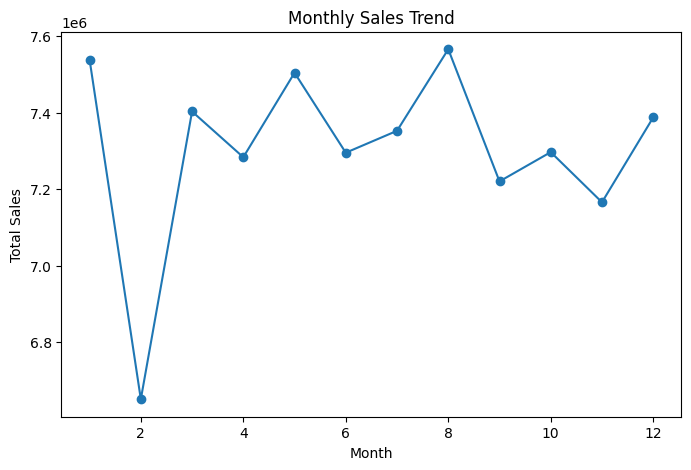

In [7]:
monthly_sales = df.groupby("Month")["TotalAmount"].sum()

plt.figure(figsize=(8,5))

monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.savefig(r"C:\Users\ACER\Downloads\EDAproject\reports\figures\monthly_sales_trend.png")

plt.show()

# Monthly sales trend

The monthly sales trend shows clear fluctuations, indicating that sales are not consistent throughout the year. A noticeable dip is observed in Month 2, while peak sales occur around Month 8. This suggests the presence of seasonality, where certain months experience higher demand, possibly due to festivals, promotions, or seasonal buying patterns.

## Findings

Sales fluctuate across months (not stable)

Month 2 shows a sharp drop

Peak sales around Month 8

Moderate recovery after dips

## Insights

Business shows seasonality

Month 2 = low demand period

Month 8 = peak demand (possible festival/offer season)

## Action:

Increase marketing in low months

Stock more inventory before peak months

## Yearly Trend

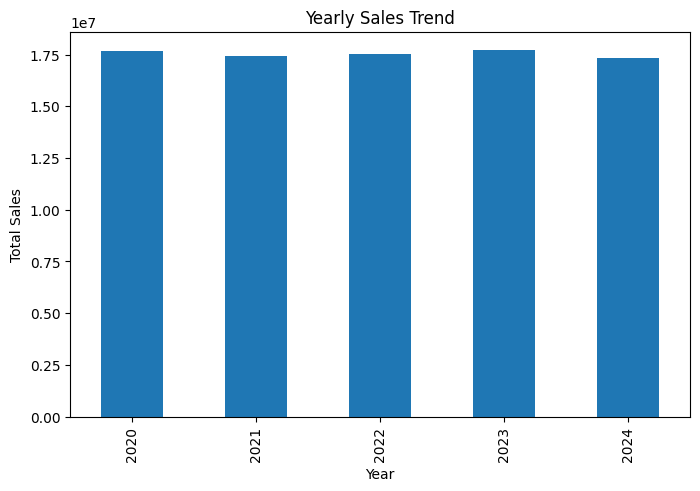

In [8]:
yearly_sales = df.groupby("Year")["TotalAmount"].sum()

plt.figure(figsize=(8,5))

yearly_sales.plot(kind="bar")

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.savefig(r"C:\Users\ACER\Downloads\EDAproject\reports\figures\yearly_sales_trend.png")

plt.show()

# Yearly sales trend

the yearly sales trend remains relatively stable with no significant increase or decrease. This indicates that while the business maintains consistent revenue, it is not experiencing strong growth.

## Findings

Sales across years are almost equal

No strong upward or downward trend

## Insights

Business is stable but not growing

Revenue is consistent year over year

## Action:

Focus on growth strategies (new markets, promotions)

# Business Analysis

## Sales by City

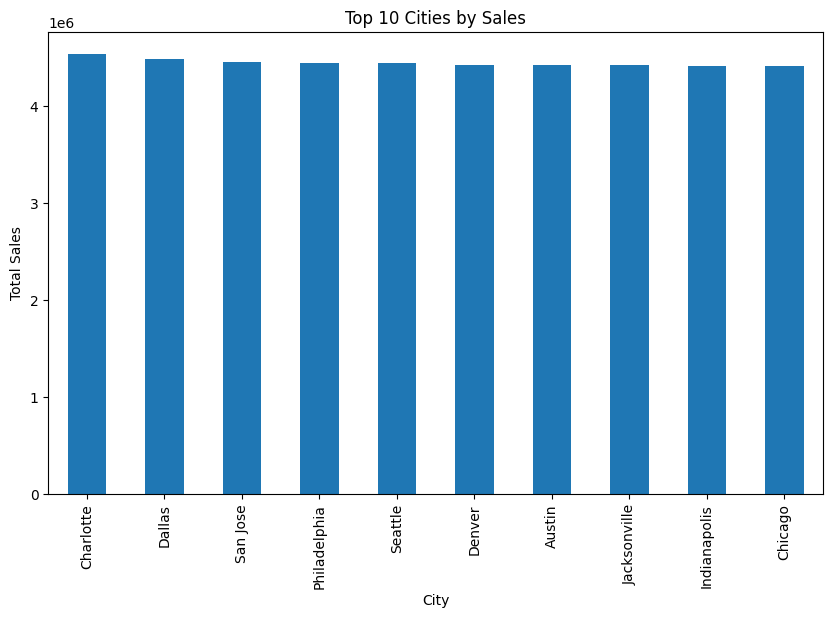

In [9]:
top_cities = df.groupby("City")["TotalAmount"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

top_cities.plot(kind="bar")

plt.title("Top 10 Cities by Sales")
plt.xlabel("City")
plt.ylabel("Total Sales")

plt.savefig(r"C:\Users\ACER\Downloads\EDAproject\reports\figures\top_cities_sales.png")

plt.show()

# Sales by City

The analysis of sales across cities shows that top cities like Charlotte, Dallas, and San Jose generate slightly higher revenue, but overall, the difference between cities is minimal. This indicates that sales are evenly distributed geographically.

## Findings

Cities like Charlotte, Dallas, San Jose lead

Sales across cities are very close

No single city dominates

## Insights

Revenue is evenly distributed geographically

No dependency on one location

## Action:

Expand operations across all cities

No need to prioritize only one city

## Sales by Category

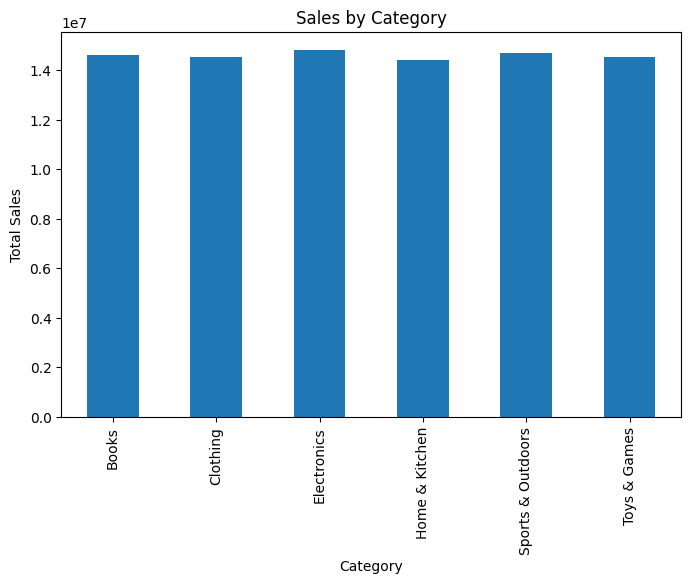

In [10]:
category_sales = df.groupby("Category")["TotalAmount"].sum()

plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.savefig(r"C:\Users\ACER\Downloads\EDAproject\reports\figures\category_sales.png")

plt.show()

# Sales by Category

Sales across different categories such as Books, Clothing, Electronics, and others are almost equal. No category significantly outperforms the others.

## Findings

All categories (Books, Clothing, Electronics, etc.) have similar sales

No category is significantly higher or lower

## Insights

Demand is balanced across product categories

Business is well diversified

## Action:

Maintain all categories

No need to eliminate any category

## Sales by Payment Method

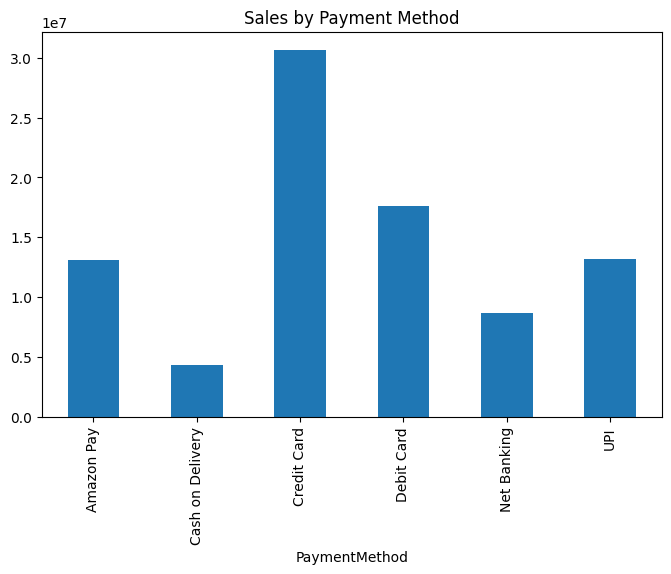

In [11]:
payment_sales = df.groupby("PaymentMethod")["TotalAmount"].sum()

plt.figure(figsize=(8,5))

payment_sales.plot(kind="bar")

plt.title("Sales by Payment Method")

plt.savefig(r"C:\Users\ACER\Downloads\EDAproject\reports\figures\payment_sales.png")

plt.show()

# Sales by Payment Method

The analysis shows that Credit Card contributes the highest sales, followed by Debit Card, while UPI and Amazon Pay show moderate usage. Cash on Delivery contributes the least.

## Findings

Credit Card → highest sales

Debit Card → second

UPI / Amazon Pay → moderate

Cash on Delivery → lowest

## Insights

Customers prefer digital payments

COD usage is declining

## Action:

Promote digital payment offers

Reduce reliance on COD

## Sales by Payment Method

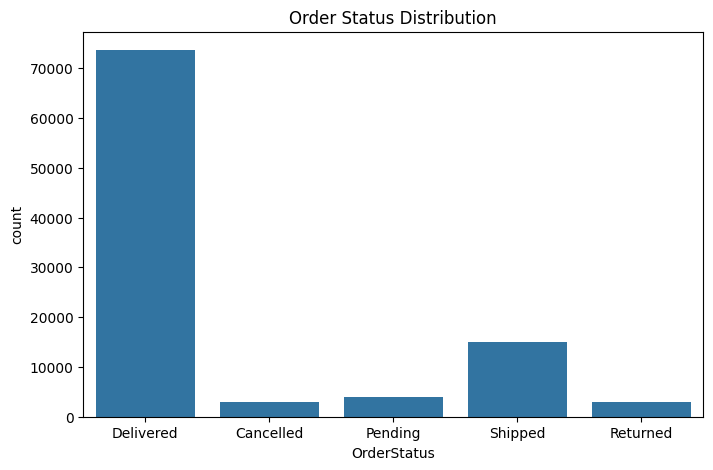

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="OrderStatus")

plt.title("Order Status Distribution")

plt.savefig(r"C:\Users\ACER\Downloads\EDAproject\reports\figures\order_status_distribution.png")

plt.show()

# Order Status Distribution

The majority of orders are successfully delivered, while shipped orders are moderate and cancellations or returns are very low.

## Findings

Delivered orders dominate

Shipped is moderate

Cancelled & Returned are very low

## Insights

Strong delivery performance

Low return rate → good product quality

Efficient logistics system

## Action:

Maintain delivery efficiency

Improve cancellation handling

## Top Sellers Analysis

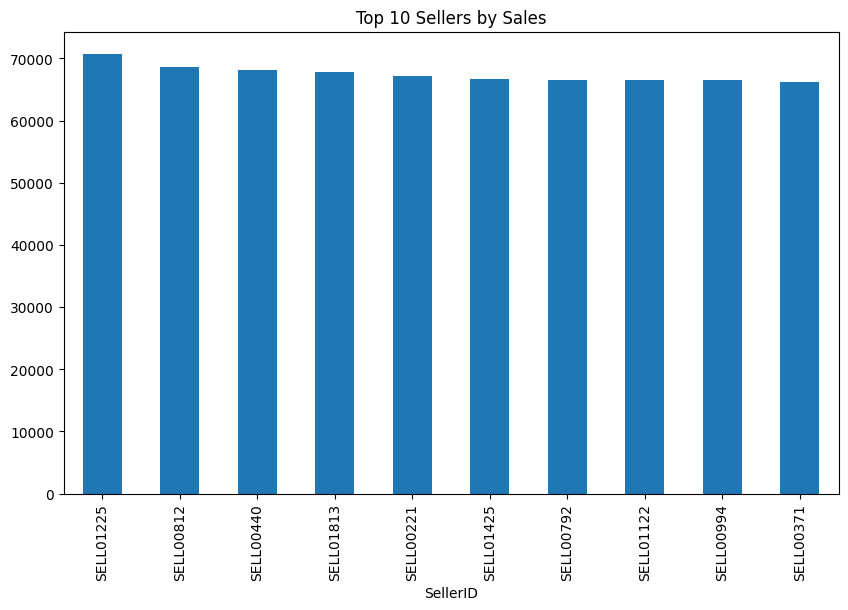

In [13]:
top_sellers = df.groupby("SellerID")["TotalAmount"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

top_sellers.plot(kind="bar")

plt.title("Top 10 Sellers by Sales")

plt.savefig(r"C:\Users\ACER\Downloads\EDAproject\reports\figures\top_sellers.png")

plt.show()

# Top Sellers Analysis

The top sellers contribute almost equally to total sales, with no single seller dominating the platform.

## Findings

Sellers have very similar sales values

No single seller dominates

## Insights

Healthy seller ecosystem

No dependency on one seller

## Action:

Support all sellers equally

Encourage competition

# STATISTICAL HYPOTHESIS TESTING

A significance level of 0.05 was used to validate key assumptions through statistical testing.

- **T-Test**: Do customers using Cash on Delivery spend more than those using Credit Card?
- **ANOVA Test**: Does product category impact the total sales amount?
- **Chi-Square Test**: Is payment method related to order status?

## T-Test

In [14]:
from scipy.stats import ttest_ind

cash_sales = df[df["PaymentMethod"] == "Cash on Delivery"]["TotalAmount"]
credit_sales = df[df["PaymentMethod"] == "Credit Card"]["TotalAmount"]

t_stat, p_value = ttest_ind(cash_sales, credit_sales)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.685664758380153
P-value: 0.4929285655117032


## ANOVA Test

In [15]:
from scipy.stats import f_oneway

groups = [group["TotalAmount"].values for name, group in df.groupby("Category")]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 1.2518982769885267
P-value: 0.28179128475810017


## Chi-Square Test

In [16]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df["PaymentMethod"], df["OrderStatus"])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("P-value:", p)

Chi-square: 14.812629723057112
P-value: 0.7870266782338731


# 1. T-Test (Cash vs Credit Card)

## Findings

P-value = 0.49 (> 0.05)

No significant difference in sales between:

Cash on Delivery

Credit Card

## Insights

Customers spend similar amounts regardless of payment method

Payment method does not influence purchase value

## Business Meaning:

No need to push one payment method for higher revenue

Focus on user convenience instead

# 2. ANOVA Test (Sales Across Categories)

## Findings

P-value = 0.28 (> 0.05)

No significant difference in sales across categories

## Insights

All product categories perform equally

No category is significantly better or worse

## Business Meaning:

Maintain all categories (balanced portfolio)

No need to prioritize or eliminate any category

## 3. Chi-Square Test (Payment Method vs Order Status)

## Findings

P-value = 0.78 (> 0.05)

No relationship between:

Payment Method

Order Status

## Insights

Payment type does not affect:

Delivery success

Cancellation

Returns

## Business Meaning:

COD is not riskier than digital payments

Order success depends on operations, not payment type

In [17]:
df.to_csv(r"C:\Users\ACER\Downloads\EDAproject\data\processed\final_dataset.csv", index=False)

# Final Insights

# Amazon E-Commerce Sales Analysis Project
Objective
Analyze e-commerce sales data to extract meaningful insights, understand business performance, and support data-driven decision making using Python.

## Project Overview
This project involves:

Data cleaning and preprocessing
Exploratory Data Analysis (EDA)
Time series analysis
Statistical testing
The goal is to identify patterns in sales, customer behavior, and operational performance.

## Data Cleaning & Preprocessing (Day 2)
Tasks Performed
Removed missing values
Handled duplicates
Corrected data types
Standardized column formats
Outcome
Clean and structured dataset ready for analysis.

## Exploratory Data Analysis (Day 3)
Analysis Performed
Sales distribution
Category-wise analysis
City-wise performance
Payment method trends
Order status distribution
Key Insights
Sales are evenly distributed across categories and cities
Digital payments are widely used
Majority of orders are successfully delivered

# Time Series Analysis (Day 4)
Feature Engineering
Extracted:

Year
Month
Day
Day of Week
Trend Analysis
Monthly sales show fluctuations → seasonality
Yearly sales remain stable → consistent business performance

## Business Insights
Geography
No single city dominates sales
Categories
Balanced performance across all product categories
Payments
Strong preference for digital payments
Operations
High delivery success rate
Low cancellation and return rates
Sellers
Equal contribution from sellers → no dependency risk

## Statistical Analysis
Tests Applied
T-Test → Payment comparison
ANOVA → Category comparison
Chi-Square → Relationship analysis
Results
No significant difference in:
Payment methods
Product categories
No relationship between:
Payment method and order status

## Insight
The system is balanced and unbiased, with no single factor strongly affecting sales.

# Final Conclusion
Overall Insights
Business is stable and consistent
Sales show seasonal patterns
Balanced distribution across:
Cities
Categories
Sellers
Strong operational performance
Increasing adoption of digital payments
No statistically significant variations across key variables

# Project Summary
This project analyzed e-commerce sales data using Python, focusing on data cleaning, EDA, time series analysis, and statistical testing. The results show a stable and well-balanced business with seasonal sales trends, strong delivery performance, and no significant differences across payment methods, categories, or order outcomes.